In [1]:
import torch
from transformers import AutoModelForCausalLM
from transformers import AutoTokenizer, EsmForMaskedLM
from tokenizers import Tokenizer
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
import os
import csv

from scipy.stats import spearmanr

/opt/anaconda3/envs/MachLearn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from plm_compare_progen2 import *
from plm_compare_esm import *
from protein_data import *

In [3]:
with open('/Users/johnhutchens/Desktop/Practicum/Data/Wild_Dictionaries/pg2_ProGym_matrices.pickle',
           'rb') as f:
    pg_dict = pickle.load(f)

In [8]:
with open('/Users/johnhutchens/Desktop/Practicum/Data/Wild_Dictionaries/esm2_ProGym_matrices.pickle',
           'rb') as f:
    esm_dict = pickle.load(f)

In [5]:
keys = list(pg_dict.keys())

In [ ]:
pg_dict[keys[6]]

dict_keys(['sequence', 'DMS', 'log_probs', 'ref_log_probs', 'llr_matrix', 'spearman_DMS'])

In [28]:
pg_sp_list=[]
esm_sp_list=[]
for key in keys:
    if 'spearman_DMS' in pg_dict[key].keys():
        pg_sp_val = pg_dict[key]['spearman_DMS']
        esm_sp_val = esm_dict[key]['spearman_DMS']

        pg_sp_list.append(pg_sp_val[0])
        esm_sp_list.append(esm_sp_val[0])

In [29]:
pg_sp_list[0]

np.float64(0.3791506937886044)

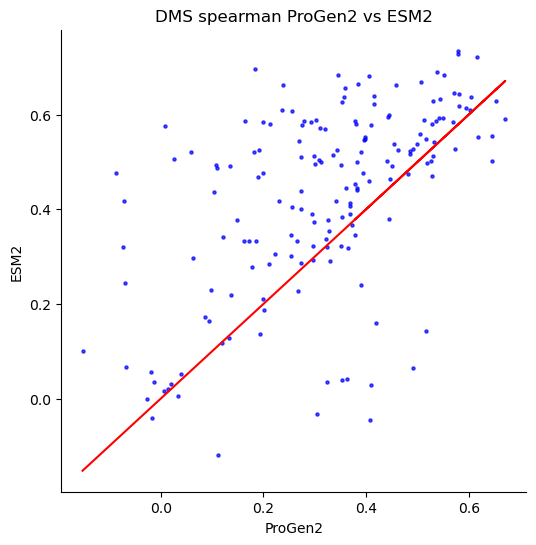

In [30]:
x = pg_sp_list
y = esm_sp_list

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(x, y, color='blue', alpha=0.7, s=5)
plt.plot(x, x, color='red')
plt.xlabel("ProGen2")
plt.ylabel("ESM2")
plt.title(f"DMS spearman ProGen2 vs ESM2")
plt.grid(False)
ax = plt.gca()
# ax.text(
#     0.01, 0.99,                
#     f"Spearman = {round(sp_val,5)}",
#     transform=plt.gca().transAxes,
#     fontsize=12,
#     verticalalignment='top',
#     horizontalalignment='left',
# )
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


plt.show()

In [31]:
label_list=[]

for key in keys:
    if 'spearman_DMS' in pg_dict[key].keys():
        pg_sp_val = pg_dict[key]['spearman_DMS']
        esm_sp_val = esm_dict[key]['spearman_DMS']

        label_list.append((key, pg_sp_val[0], esm_sp_val[0]))

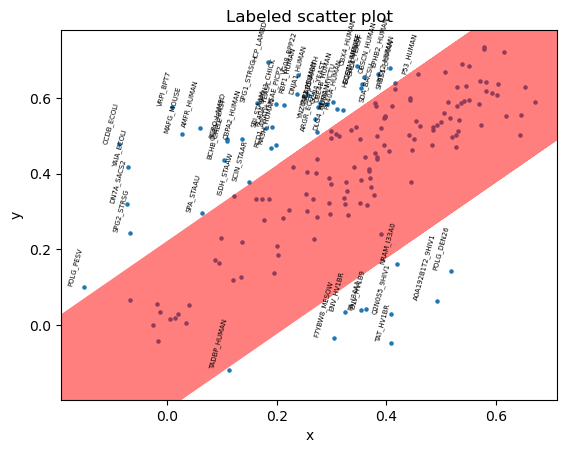

In [64]:
labels = [d[0] for d in label_list]
x = [d[1] for d in label_list]
y = [d[2] for d in label_list]

plt.figure()
plt.scatter(x, y, s=5)
plt.plot(x,x, color='red', alpha=0.5, lw=100)

t = 0.2

for label, xi, yi in label_list:
    if xi > t+yi or yi > t+xi:
        plt.text(xi, yi, label, ha='right',
    va='bottom', rotation=75, fontsize=5)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Labeled scatter plot")
plt.show()

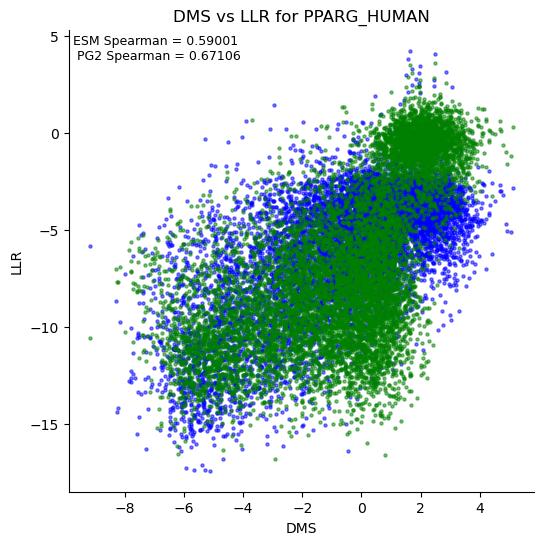

In [70]:
i = 25

x = esm_dict[keys[i]]['DMS']
y1 = esm_dict[keys[i]]['llr_matrix']
y2 = pg_dict[keys[i]]['llr_matrix']

sp_val_esm, p_val_esm = esm_dict[keys[i]]['spearman_DMS']
sp_val_pg, p_val_pg = pg_dict[keys[i]]['spearman_DMS']

mask1 = ~np.isnan(x) & ~np.isnan(y1)
x_clean = x[mask1]
y1_clean = y1[mask1]

mask2 = ~np.isnan(x) & ~np.isnan(y2)
x_clean = x[mask2]
y2_clean = y2[mask2]



# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(x_clean, y1_clean, color='blue', alpha=0.5, s=5)
plt.scatter(x_clean, y2_clean, color='green', alpha=0.5, s=5)
plt.xlabel("DMS")
plt.ylabel("LLR")
plt.title(f"DMS vs LLR for {keys[i]}")
plt.grid(False)
ax = plt.gca()
ax.text(
    0.01, 0.99,                
    f"ESM Spearman = {round(sp_val_esm,5)} \n PG2 Spearman = {round(sp_val_pg,5)}",
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='left',
)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


plt.show()

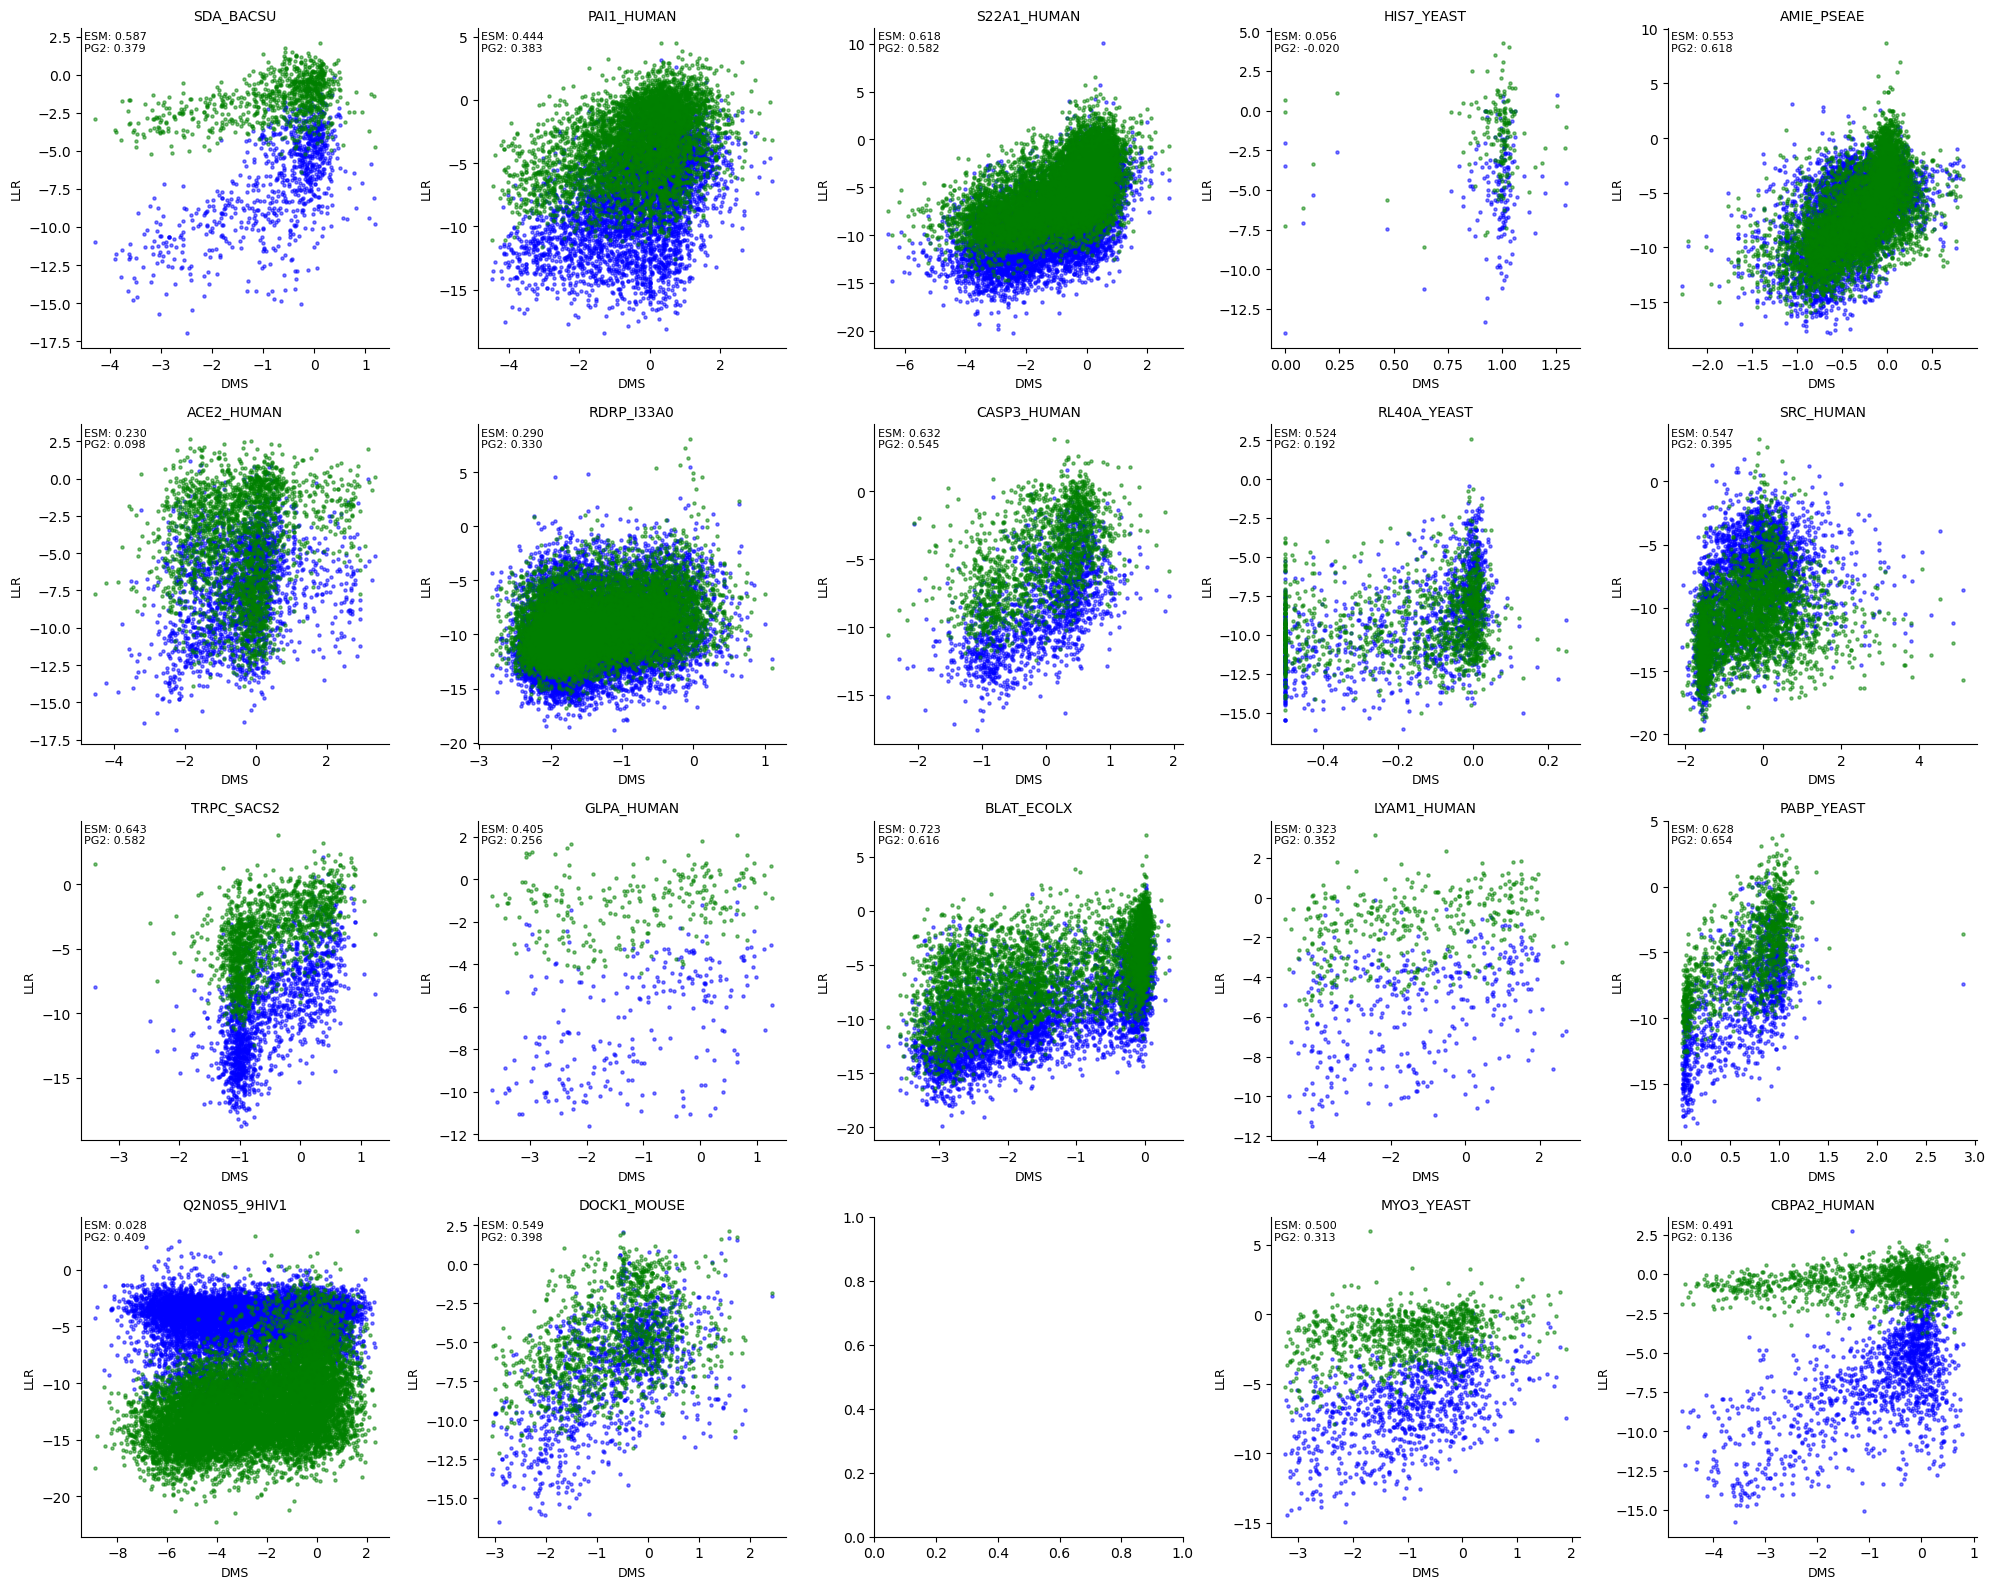

In [72]:

indices = list(range(20))  # or any 20 values of i
nrows, ncols = 4, 5

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 16))
axes = axes.flatten()  # flatten to 1D array for easy iteration

for idx, i in enumerate(indices):
    ax = axes[idx]
    
    if 'llr_matrix' in pg_dict[keys[i]].keys():

        x = esm_dict[keys[i]]['DMS']
        y1 = esm_dict[keys[i]]['llr_matrix']
        y2 = pg_dict[keys[i]]['llr_matrix']
        
        sp_val_esm, _ = esm_dict[keys[i]]['spearman_DMS']
        sp_val_pg, _ = pg_dict[keys[i]]['spearman_DMS']
        
        # Clean NaNs
        mask1 = ~np.isnan(x) & ~np.isnan(y1)
        mask2 = ~np.isnan(x) & ~np.isnan(y2)
        
        x1_clean, y1_clean = x[mask1], y1[mask1]
        x2_clean, y2_clean = x[mask2], y2[mask2]
        
        # Scatter plots
        ax.scatter(x1_clean, y1_clean, color='blue', alpha=0.5, s=5, label='ESM')
        ax.scatter(x2_clean, y2_clean, color='green', alpha=0.5, s=5, label='PG2')
        
        # Axes labels
        ax.set_xlabel("DMS", fontsize=9)
        ax.set_ylabel("LLR", fontsize=9)
        
        # Title
        ax.set_title(keys[i], fontsize=10)
        
        # Spearman annotations
        ax.text(
            0.01, 0.99,
            f"ESM: {sp_val_esm:.3f}\nPG2: {sp_val_pg:.3f}",
            transform=ax.transAxes,
            fontsize=8,
            verticalalignment='top',
            horizontalalignment='left'
        )
    
    # Remove top/right spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    # Optional: grid off
    ax.grid(False)

# Adjust spacing
plt.tight_layout()
plt.show()


In [79]:
esm_sp_list = []
pg_sp_list = []

for key in pg_dict.keys():
    if 'spearman_DMS' in pg_dict[key].keys():
        esm_sp, _ = esm_dict[key]['spearman_DMS']
        pg_sp, _ = pg_dict[key]['spearman_DMS']

        esm_sp_list.append(esm_sp)
        pg_sp_list.append(pg_sp)

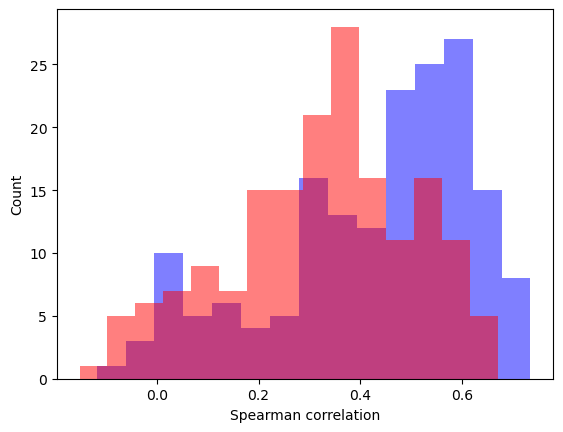

In [83]:
plt.figure()
plt.hist(esm_sp_list, bins=15, color = 'blue', alpha = 0.5)
plt.hist(pg_sp_list, bins=15, color = 'red', alpha = 0.5)
plt.xlabel("Spearman correlation")
plt.ylabel("Count")

plt.show()

In [85]:
for key in keys:
    if 'llr_matrix' in pg_dict[key].keys():
        esm_llr = esm_dict[key]['llr_matrix']
        pg_llr = pg_dict[key]['llr_matrix']
        sp = spearman_ignore_nan(esm_llr, pg_llr)
        print(key, sp[0])

SDA_BACSU 0.8171853557238675
PAI1_HUMAN 0.8957314979071973
S22A1_HUMAN 0.8159041910289297
HIS7_YEAST 0.8919918117336236
AMIE_PSEAE 0.6590884653683963
ACE2_HUMAN 0.7799516043202911
RDRP_I33A0 0.5104022837977994
CASP3_HUMAN 0.8419376494707026
RL40A_YEAST 0.6131664696948294
SRC_HUMAN 0.7348086752341307
TRPC_SACS2 0.8127027146529779
GLPA_HUMAN 0.7915606027491682
BLAT_ECOLX 0.8321054650063874
LYAM1_HUMAN 0.9143962323363601
PABP_YEAST 0.7978044439134595
Q2N0S5_9HIV1 0.2778930295651284
DOCK1_MOUSE 0.6440108688774893
MYO3_YEAST 0.7393567373734278
CBPA2_HUMAN 0.41673304800658884
RAD_ANTMA 0.6077144289010795
A4D664_9INFA 0.3818605093846687
CATR_CHLRE 0.7355471442364147
SERC_HUMAN 0.8895684820017684
SRBS1_HUMAN 0.7025973514418494
PPARG_HUMAN 0.6708197582611627
AICDA_HUMAN 0.7349478941280498
AACC1_PSEAI 0.858035272051438
A4_HUMAN 0.6072952382607204
RS15_GEOSE 0.7483284727665259
P53_HUMAN 0.6916442162637583
VG08_BPP22 0.6956455351657369
OXDA_RHOTO 0.8490562167538731
AMFR_HUMAN 0.5100244710379477
DY

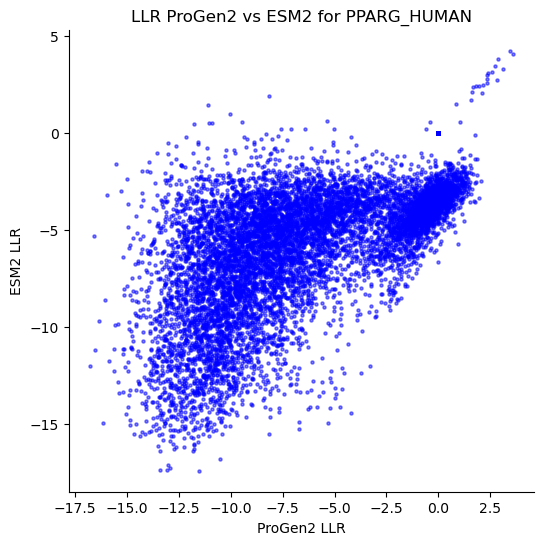

In [89]:
i = 25

x = pg_dict[keys[i]]['llr_matrix']
y = esm_dict[keys[i]]['llr_matrix']

mask = ~np.isnan(x) & ~np.isnan(y)
x_clean = x[mask]
y_clean = y[mask]

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(x_clean, y_clean, color='blue', alpha=0.5, s=5)
plt.xlabel("ProGen2 LLR")
plt.ylabel("ESM2 LLR")
plt.title(f"LLR ProGen2 vs ESM2 for {keys[i]}")
plt.grid(False)
ax = plt.gca()
# ax.text(
#     0.01, 0.99,                
#     f"ESM Spearman = {round(sp_val_esm,5)} \n PG2 Spearman = {round(sp_val_pg,5)}",
#     transform=plt.gca().transAxes,
#     fontsize=9,
#     verticalalignment='top',
#     horizontalalignment='left',
# )
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


plt.show()